# **Lets First Import all the Necessary Libraries we gonna**

In [33]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder , StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import Perceptron

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import Flatten

from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Dropout

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

# **Now I already have training data and one testing data so i am importing both in this.**

In [3]:
training_dataset = pd.read_csv("/content/mnist_train.csv")
testing_dataset = pd.read_csv("/content/mnist_test.csv")

In [4]:
training_dataset.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
training_dataset.shape

(60000, 785)

In [6]:
training_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, label to 28x28
dtypes: int64(785)
memory usage: 359.3 MB


In [7]:
training_dataset.isnull().sum()

,0
label,0
1x1,0
1x2,0
1x3,0
1x4,0
...,...
28x24,0
28x25,0
28x26,0
28x27,0


# **Now Lets first make a simple perceptron model no CNN no ANN**

In [8]:
x_train = training_dataset.drop ("label", axis=1). values
y_train = training_dataset["label"]. values
x_test = testing_dataset.drop("label", axis=1).values
y_test = testing_dataset["label"].values

In [9]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

In [10]:
x_train_img = x_train.reshape(-1 , 28 , 28)
x_test_img = x_test.reshape(-1 , 28 , 28)

In [11]:
 y_train_cat = to_categorical(y_train , 10)
 y_test_cat = to_categorical(y_test , 10 )

In [12]:
perceptron = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(10 , activation="softmax")
])

In [13]:
perceptron.compile(
    optimizer = "adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]

)

In [25]:
history = perceptron.fit(
    x_train_img,
    y_train_cat,
    epochs=15,
    validation_split=0.2,
    validation_data=(x_test_img , y_test_cat),
    verbose=1
)

Epoch 1/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9311 - loss: 0.2490 - val_accuracy: 0.9268 - val_loss: nan
Epoch 2/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9311 - loss: 0.2482 - val_accuracy: 0.9260 - val_loss: nan
Epoch 3/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9323 - loss: 0.2465 - val_accuracy: 0.9247 - val_loss: nan
Epoch 4/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9324 - loss: 0.2453 - val_accuracy: 0.9249 - val_loss: nan
Epoch 5/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9331 - loss: 0.2440 - val_accuracy: 0.9263 - val_loss: nan
Epoch 6/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9329 - loss: 0.2428 - val_accuracy: 0.9246 - val_loss: nan
Epoch 7/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9337 - loss: 0.2423 - val_accuracy: 0.9250 - val_loss: nan
Epoch 8/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9334 - loss: 0.2408 - val_accuracy: 0.9258 

In [26]:
accuracy = perceptron.evaluate(x_test_img , y_test_cat , verbose=0)[1]
print(accuracy)

0.9251276254653931


# **Now lets see what ANN can do on this so lets Make a ANN model we dont have to do anything new just the perceptron model we have built above we just simply add more dense hidden layers for better processing and better training**

In [27]:
ann = Sequential([
     Flatten(input_shape=(28,28)),
     Dense(128 , activation="relu"),
     Dense(64 , activation="relu"),
     Dense(32 , activation="relu"),
     Dense(10 , activation="softmax")
 ])

In [36]:
opt = Adam(learning_rate=0.001)
ann.compile(
    optimizer=opt,
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [37]:
ann_history = ann.fit(
    x_train_img,
    y_train_cat,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    validation_data=(x_test_img , y_test_cat),
    verbose=1
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9890 - loss: 0.0468 - val_accuracy: 0.9779 - val_loss: nan
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9920 - loss: 0.0294 - val_accuracy: 0.9786 - val_loss: nan
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9934 - loss: 0.0236 - val_accuracy: 0.9782 - val_loss: nan
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9942 - loss: 0.0200 - val_accuracy: 0.9784 - val_loss: nan
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9948 - loss: 0.0173 - val_accuracy: 0.9787 - val_loss: nan
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9954 - loss: 0.0145 - val_accuracy: 0.9778 - val_loss: nan
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9961 - loss: 0.0126 - val_accuracy: 0.9779 - val_loss: nan
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9964 - loss: 0.0116 - val_accuracy: 0.9

In [38]:
ann_accuracy = ann.evaluate(x_test_img , y_test_cat , verbose=0)[1]
print(ann_accuracy)

0.9785403609275818


# **Now as we can see perceptron gives around 92 accuracy and using ann we got around 97 accuracy althought both are good accuracies and both perceptron and ann works good , but not best now lets use CNN for this and then see what happens**

In [40]:
x_train_cnn = x_train.reshape(-1 , 28 , 28 , 1)
x_test_cnn = x_test.reshape(-1 , 28 , 28 , 1)

In [41]:
cnn = Sequential([
    Conv2D(32 , input_shape=(28,28,1) , kernel_size=(3,3) , activation="relu"),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64 , kernel_size=(3,3) , activation="relu"),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(128 , activation="relu"),
    Dropout(0.5),
    Dense(10 , activation="softmax")
])

In [42]:
new_opt = Adam(learning_rate=0.001)
cnn.compile(
    optimizer= new_opt,
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [44]:
cnn_history = cnn.fit(
    x_train_cnn , y_train_cat,
    epochs=10,
    batch_size = 32,
    validation_split=0.2,
    validation_data=(x_test_cnn , y_test_cat),
    verbose=1
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 56s 29ms/step - accuracy: 0.9391 - loss: 0.2000 - val_accuracy: 0.9857 - val_loss: nan
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 29ms/step - accuracy: 0.9771 - loss: 0.0758 - val_accuracy: 0.9865 - val_loss: nan
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 52s 28ms/step - accuracy: 0.9835 - loss: 0.0548 - val_accuracy: 0.9913 - val_loss: nan
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 28ms/step - accuracy: 0.9862 - loss: 0.0456 - val_accuracy: 0.9908 - val_loss: nan
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 29ms/step - accuracy: 0.9893 - loss: 0.0359 - val_accuracy: 0.9927 - val_loss: nan
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 52s 28ms/step - accuracy: 0.9898 - loss: 0.0328 - val_accuracy: 0.9923 - val_loss: nan
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 84s 29ms/step - accuracy: 0.9913 - loss: 0.0275 - val_accuracy: 0.9893 - val_loss: nan
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 51s 27ms/step - accuracy: 0.9930 - loss: 0.0235 - val_a

In [45]:
cnn_accuracy = cnn.evaluate(x_test_cnn , y_test_cat , verbose=0)[1]
print(cnn_accuracy)

0.993004322052002


In [62]:
def plot_training(history, title):
  plt.figure(figsize=(12,4))
  plt.subplot (1,2,1)
  plt.plot(history.history['accuracy'], label="Train")
  plt.plot(history.history['val_accuracy'], label="Val")
  plt.title(f"{title} Accuracy")
  plt.legend()

  plt.subplot (1,2, 2)
  plt. plot(history.history['loss'], label="Train")
  plt.plot(history.history['val_loss'], label="Val")
  plt.title(f"{title} Loss")
  plt.legend ()
  plt.show()

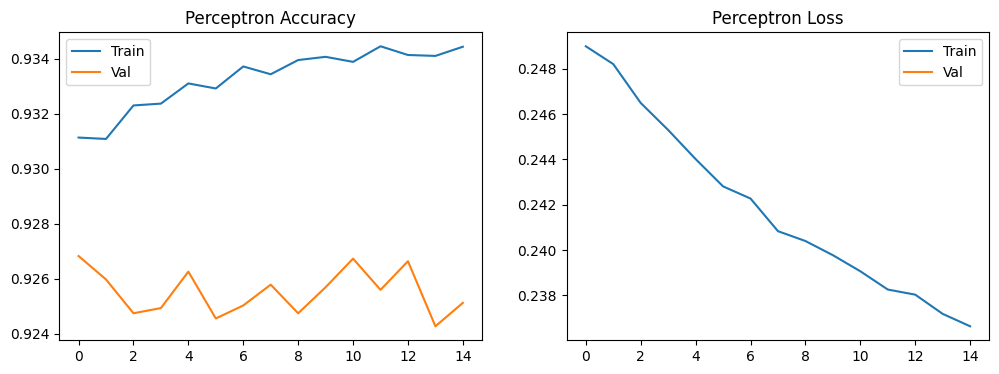

In [63]:
plot_training(history , "Perceptron")

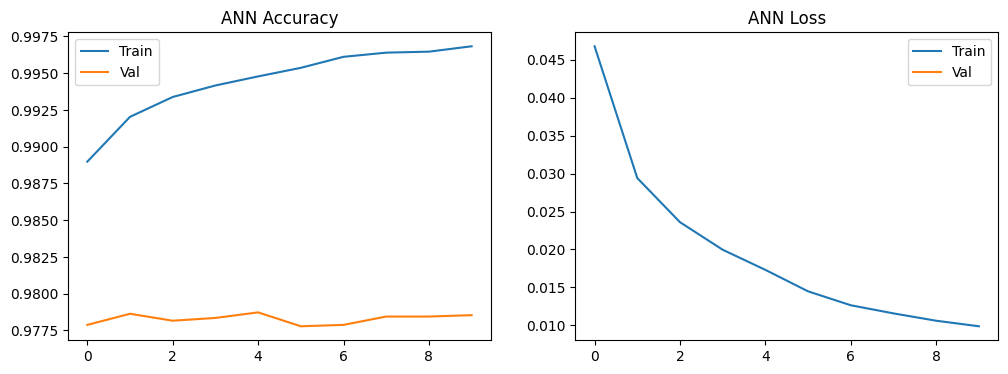

In [58]:
plot_training(ann_history , "ANN")

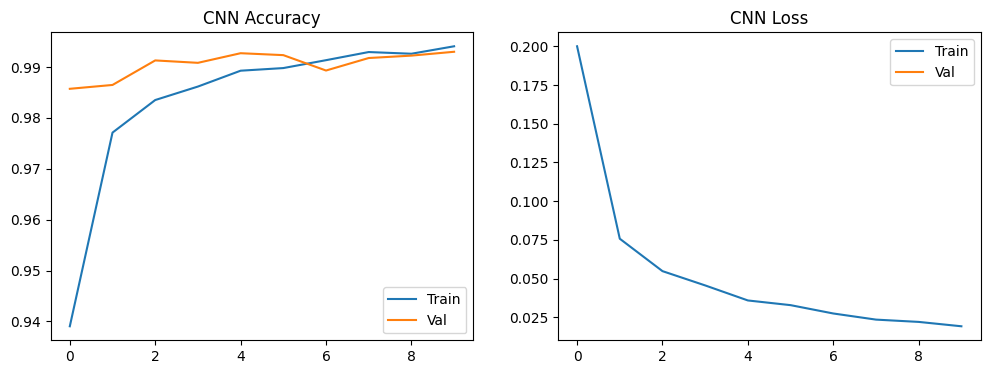

In [59]:
plot_training(cnn_history , "CNN")

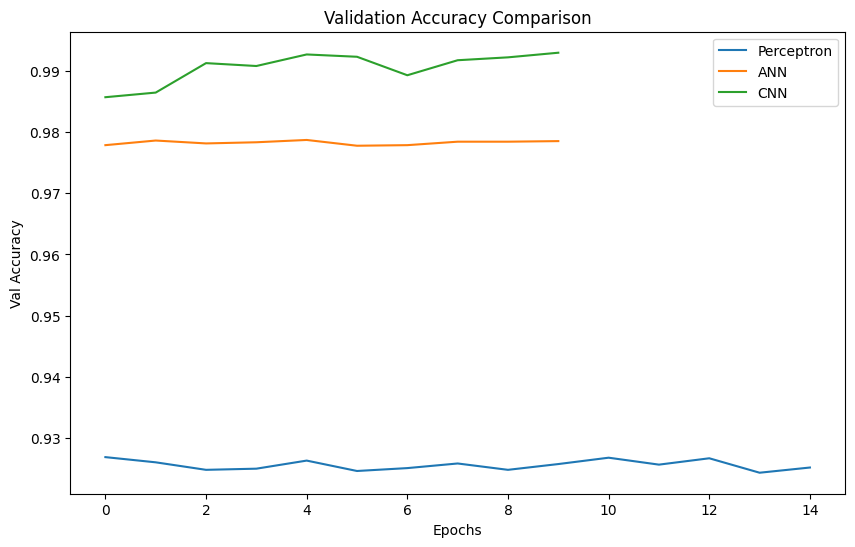

In [67]:
plt.figure(figsize=(10,6))

plt.plot(history.history['val_accuracy'], label="Perceptron")
plt.plot(ann_history.history['val_accuracy'], label="ANN")
plt.plot(cnn_history.history['val_accuracy'], label="CNN")

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Val Accuracy")

plt.legend()
plt.show()

### Confusion Matrix for CNN Model

331/331 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step


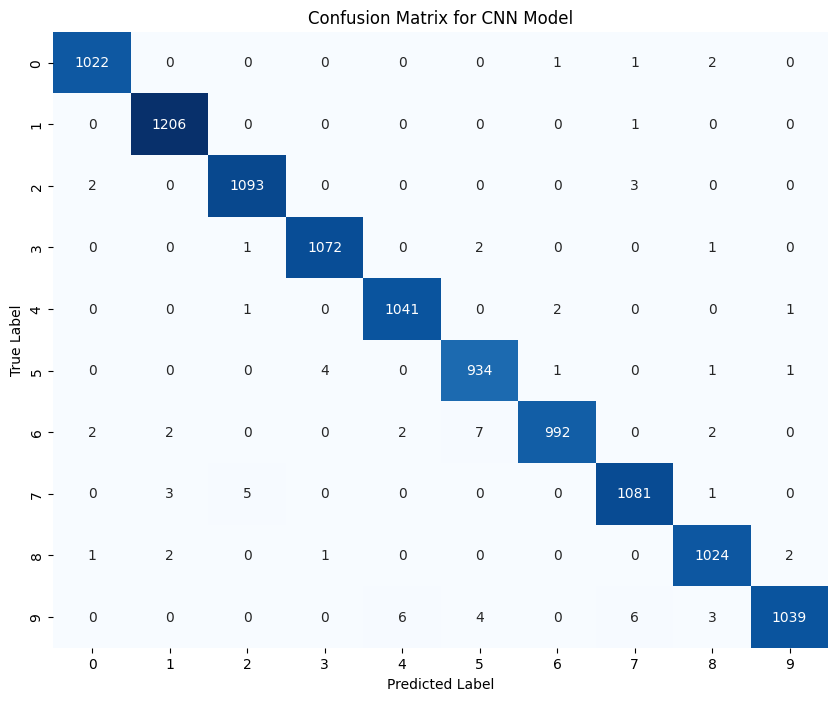

In [80]:
y_pred_cnn = cnn.predict(x_test_cnn)
y_pred_cnn_classes = np.argmax(y_pred_cnn, axis=1)
y_true_cnn_classes = np.argmax(y_test_cat, axis=1)

conf_matrix_cnn = confusion_matrix(y_true_cnn_classes, y_pred_cnn_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_cnn, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for CNN Model')
plt.show()

### Final Test Accuracy Comparison

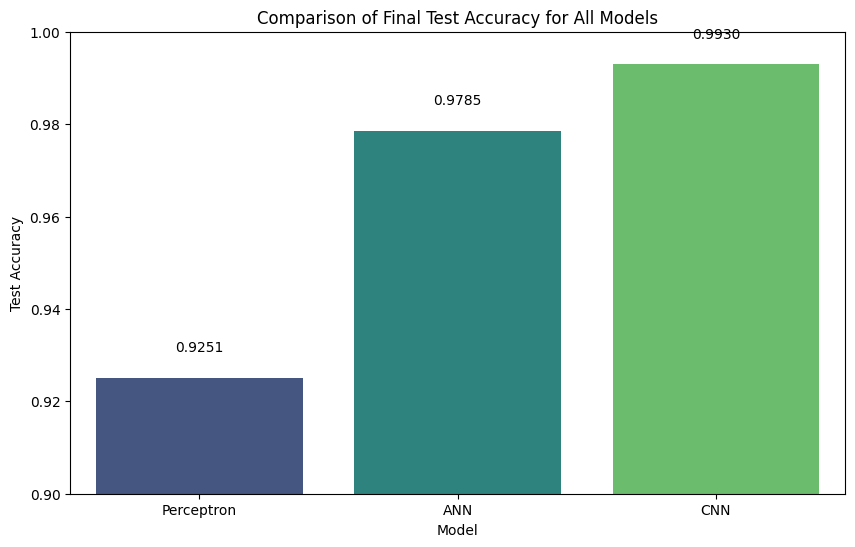

In [82]:
model_names = ['Perceptron', 'ANN', 'CNN']
final_accuracies = [accuracy, ann_accuracy, cnn_accuracy]

plt.figure(figsize=(10, 6))
sns.barplot(x=model_names, y=final_accuracies, palette='viridis')
plt.title('Comparison of Final Test Accuracy for All Models')
plt.xlabel('Model')
plt.ylabel('Test Accuracy')
plt.ylim(0.9, 1.0)


for index, value in enumerate(final_accuracies):
    plt.text(index, value + 0.005, f'{value:.4f}', ha='center', va='bottom')

plt.show()